In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer as si

In [27]:
df = pd.read_csv('planets.csv')

In [28]:
df

,method,number,orbital_period,mass,distance,year
0,Radial Velocity,1,269.300000,7.10,77.40,2006
1,Radial Velocity,1,874.774000,2.21,56.95,2008
2,Radial Velocity,1,763.000000,2.60,19.84,2011
3,Radial Velocity,1,326.030000,19.40,110.62,2007
4,Radial Velocity,1,516.220000,10.50,119.47,2009
...,...,...,...,...,...,...
1030,Transit,1,3.941507,NaN,172.00,2006
1031,Transit,1,2.615864,NaN,148.00,2007
1032,Transit,1,3.191524,NaN,174.00,2007
1033,Transit,1,4.125083,NaN,293.00,2008


In [29]:
df.shape


(1035, 6)

In [30]:
df.head()

,method,number,orbital_period,mass,distance,year
0,Radial Velocity,1,269.300,7.10,77.40,2006
1,Radial Velocity,1,874.774,2.21,56.95,2008
2,Radial Velocity,1,763.000,2.60,19.84,2011
3,Radial Velocity,1,326.030,19.40,110.62,2007
4,Radial Velocity,1,516.220,10.50,119.47,2009


In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1035 entries, 0 to 1034
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   method          1035 non-null   str    
 1   number          1035 non-null   int64  
 2   orbital_period  992 non-null    float64
 3   mass            513 non-null    float64
 4   distance        808 non-null    float64
 5   year            1035 non-null   int64  
dtypes: float64(3), int64(2), str(1)
memory usage: 48.6 KB


In [32]:
df.isnull()

,method,number,orbital_period,mass,distance,year
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
...,...,...,...,...,...,...
1030,False,False,False,True,False,False
1031,False,False,False,True,False,False
1032,False,False,False,True,False,False
1033,False,False,False,True,False,False


In [33]:
df.isnull().sum()

method              0
number              0
orbital_period     43
mass              522
distance          227
year                0
dtype: int64

In [34]:
df.isnull().sum().sum()

np.int64(792)

<Axes: >

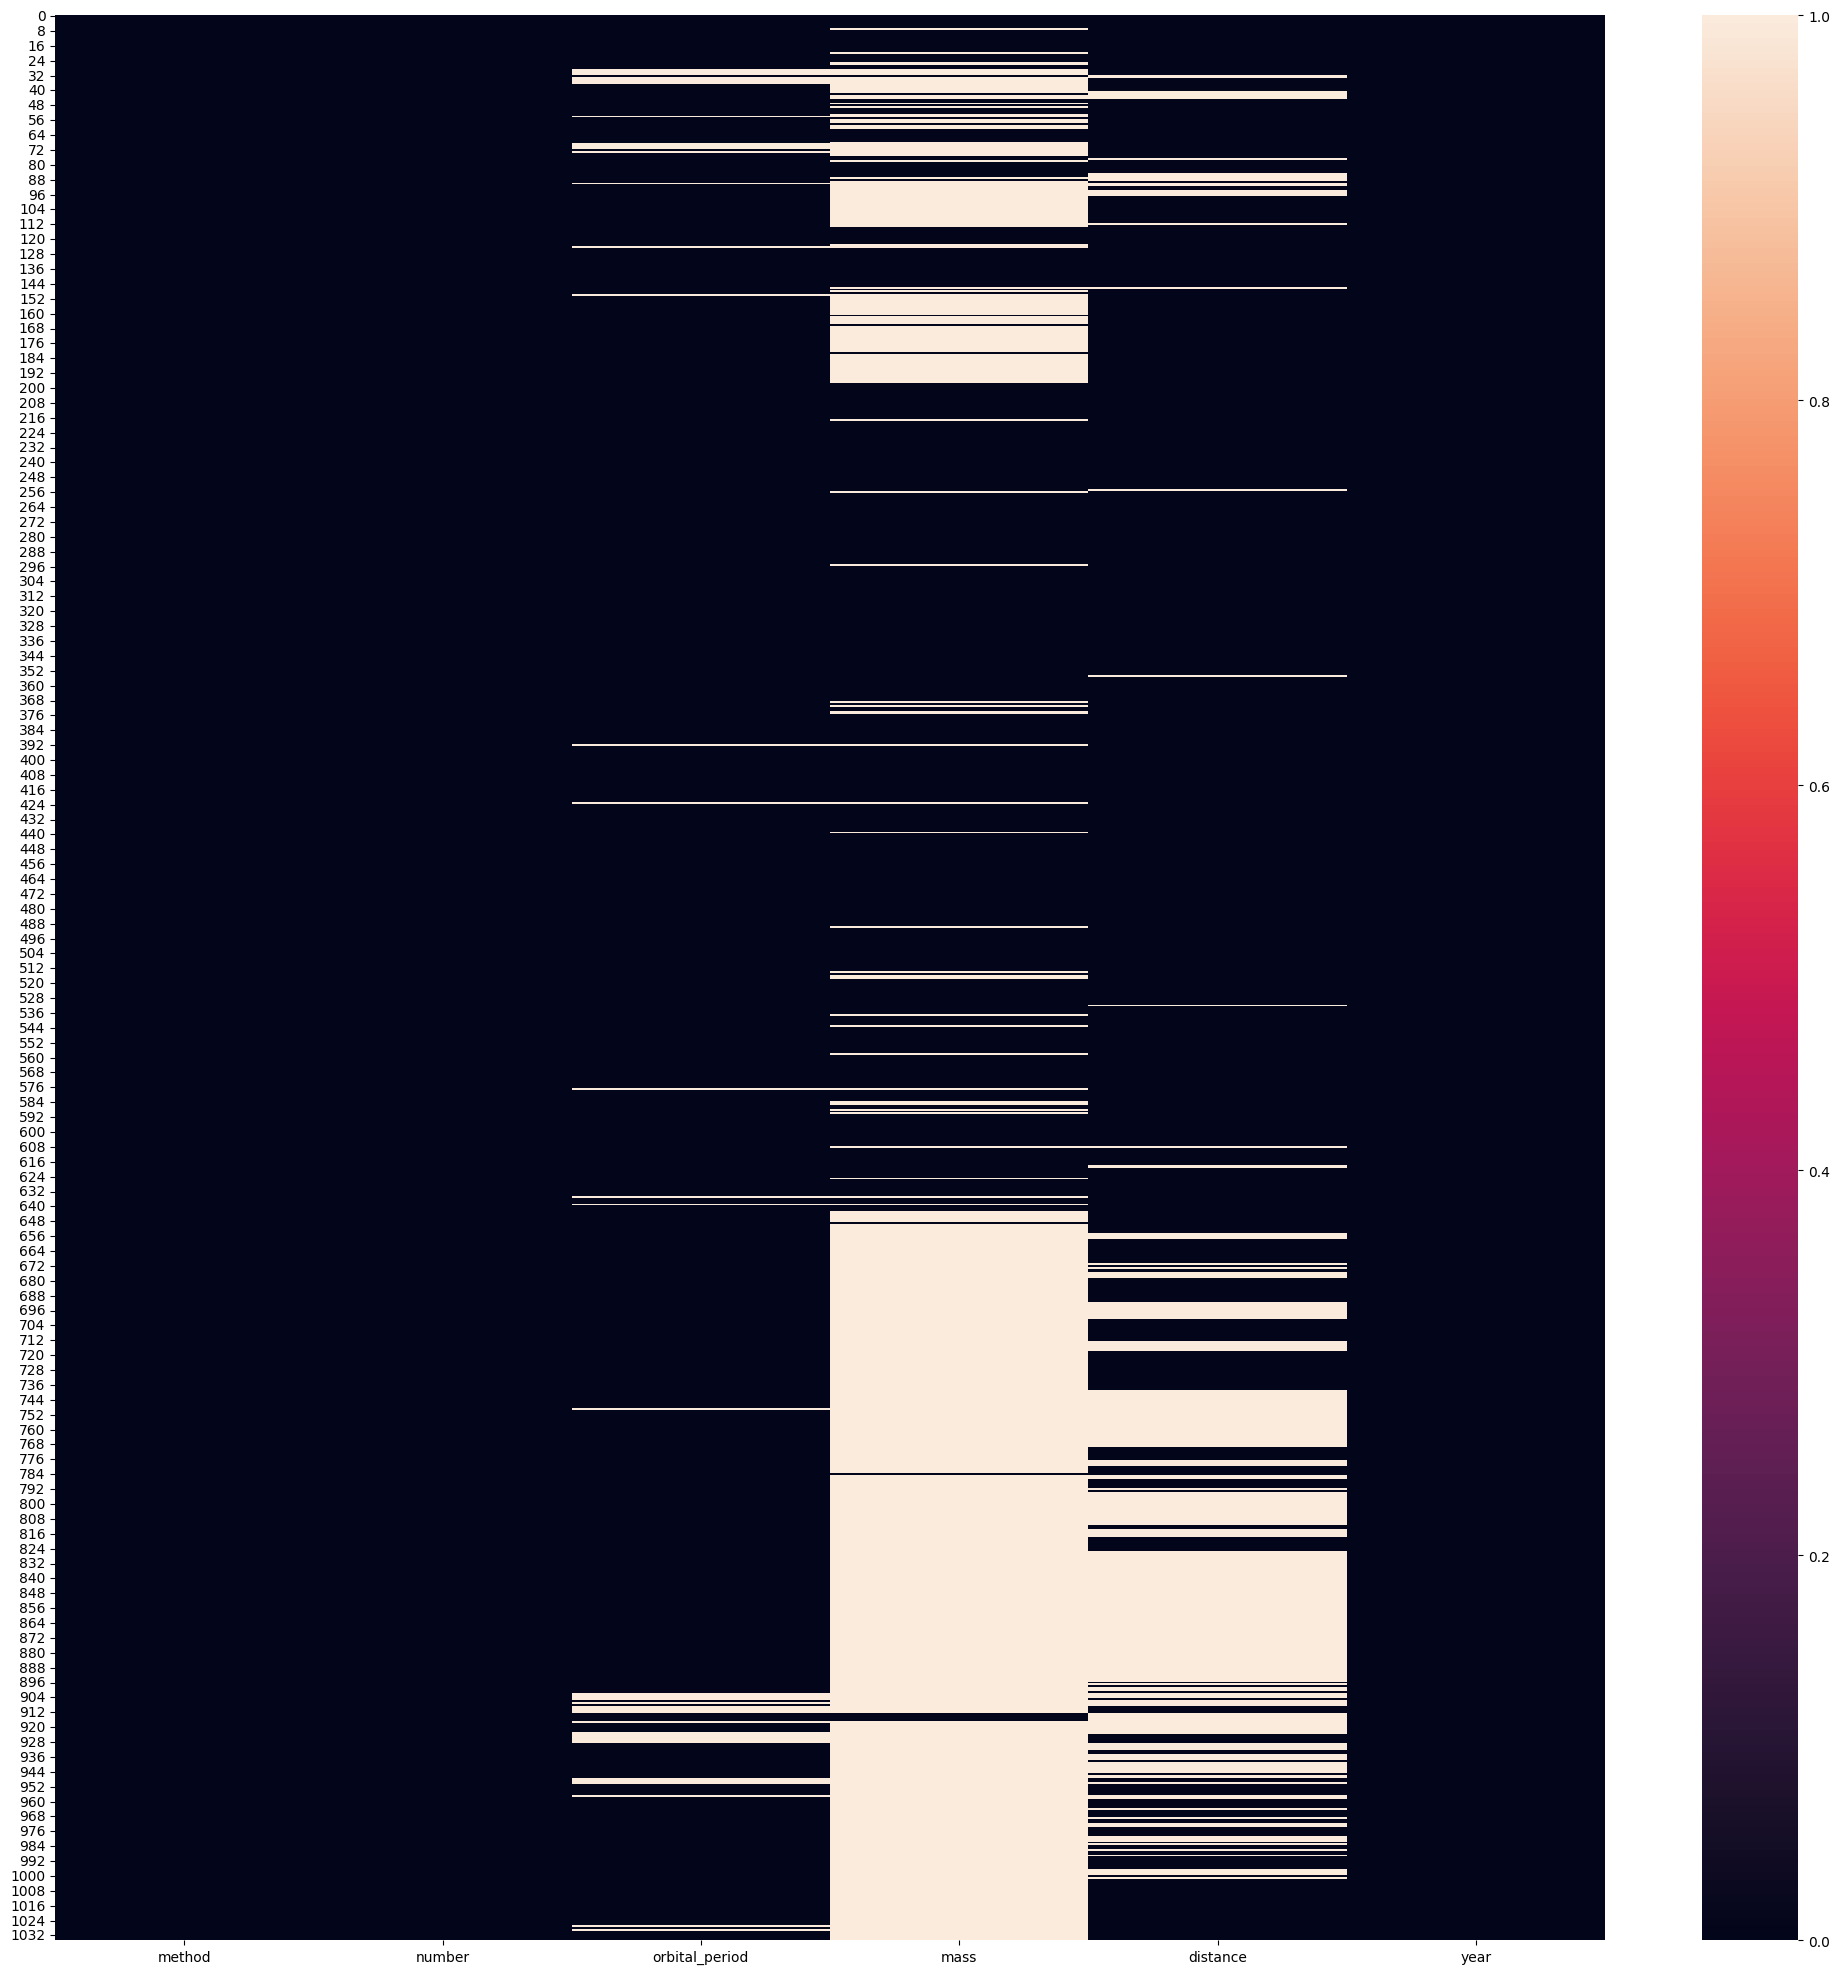

In [35]:
plt.figure(figsize = (25, 25))
sns.heatmap(df.isnull())

In [36]:
null_val = df.isnull().sum()/df.shape[0]*100


In [37]:
null_val

method             0.000000
number             0.000000
orbital_period     4.154589
mass              50.434783
distance          21.932367
year               0.000000
dtype: float64

In [38]:
d_col = null_val[null_val > 21].keys()
d_col

Index(['mass', 'distance'], dtype='str')

In [39]:
df2_d_col = df.drop(columns=d_col)
df2_d_col.shape

(1035, 4)

<Axes: >

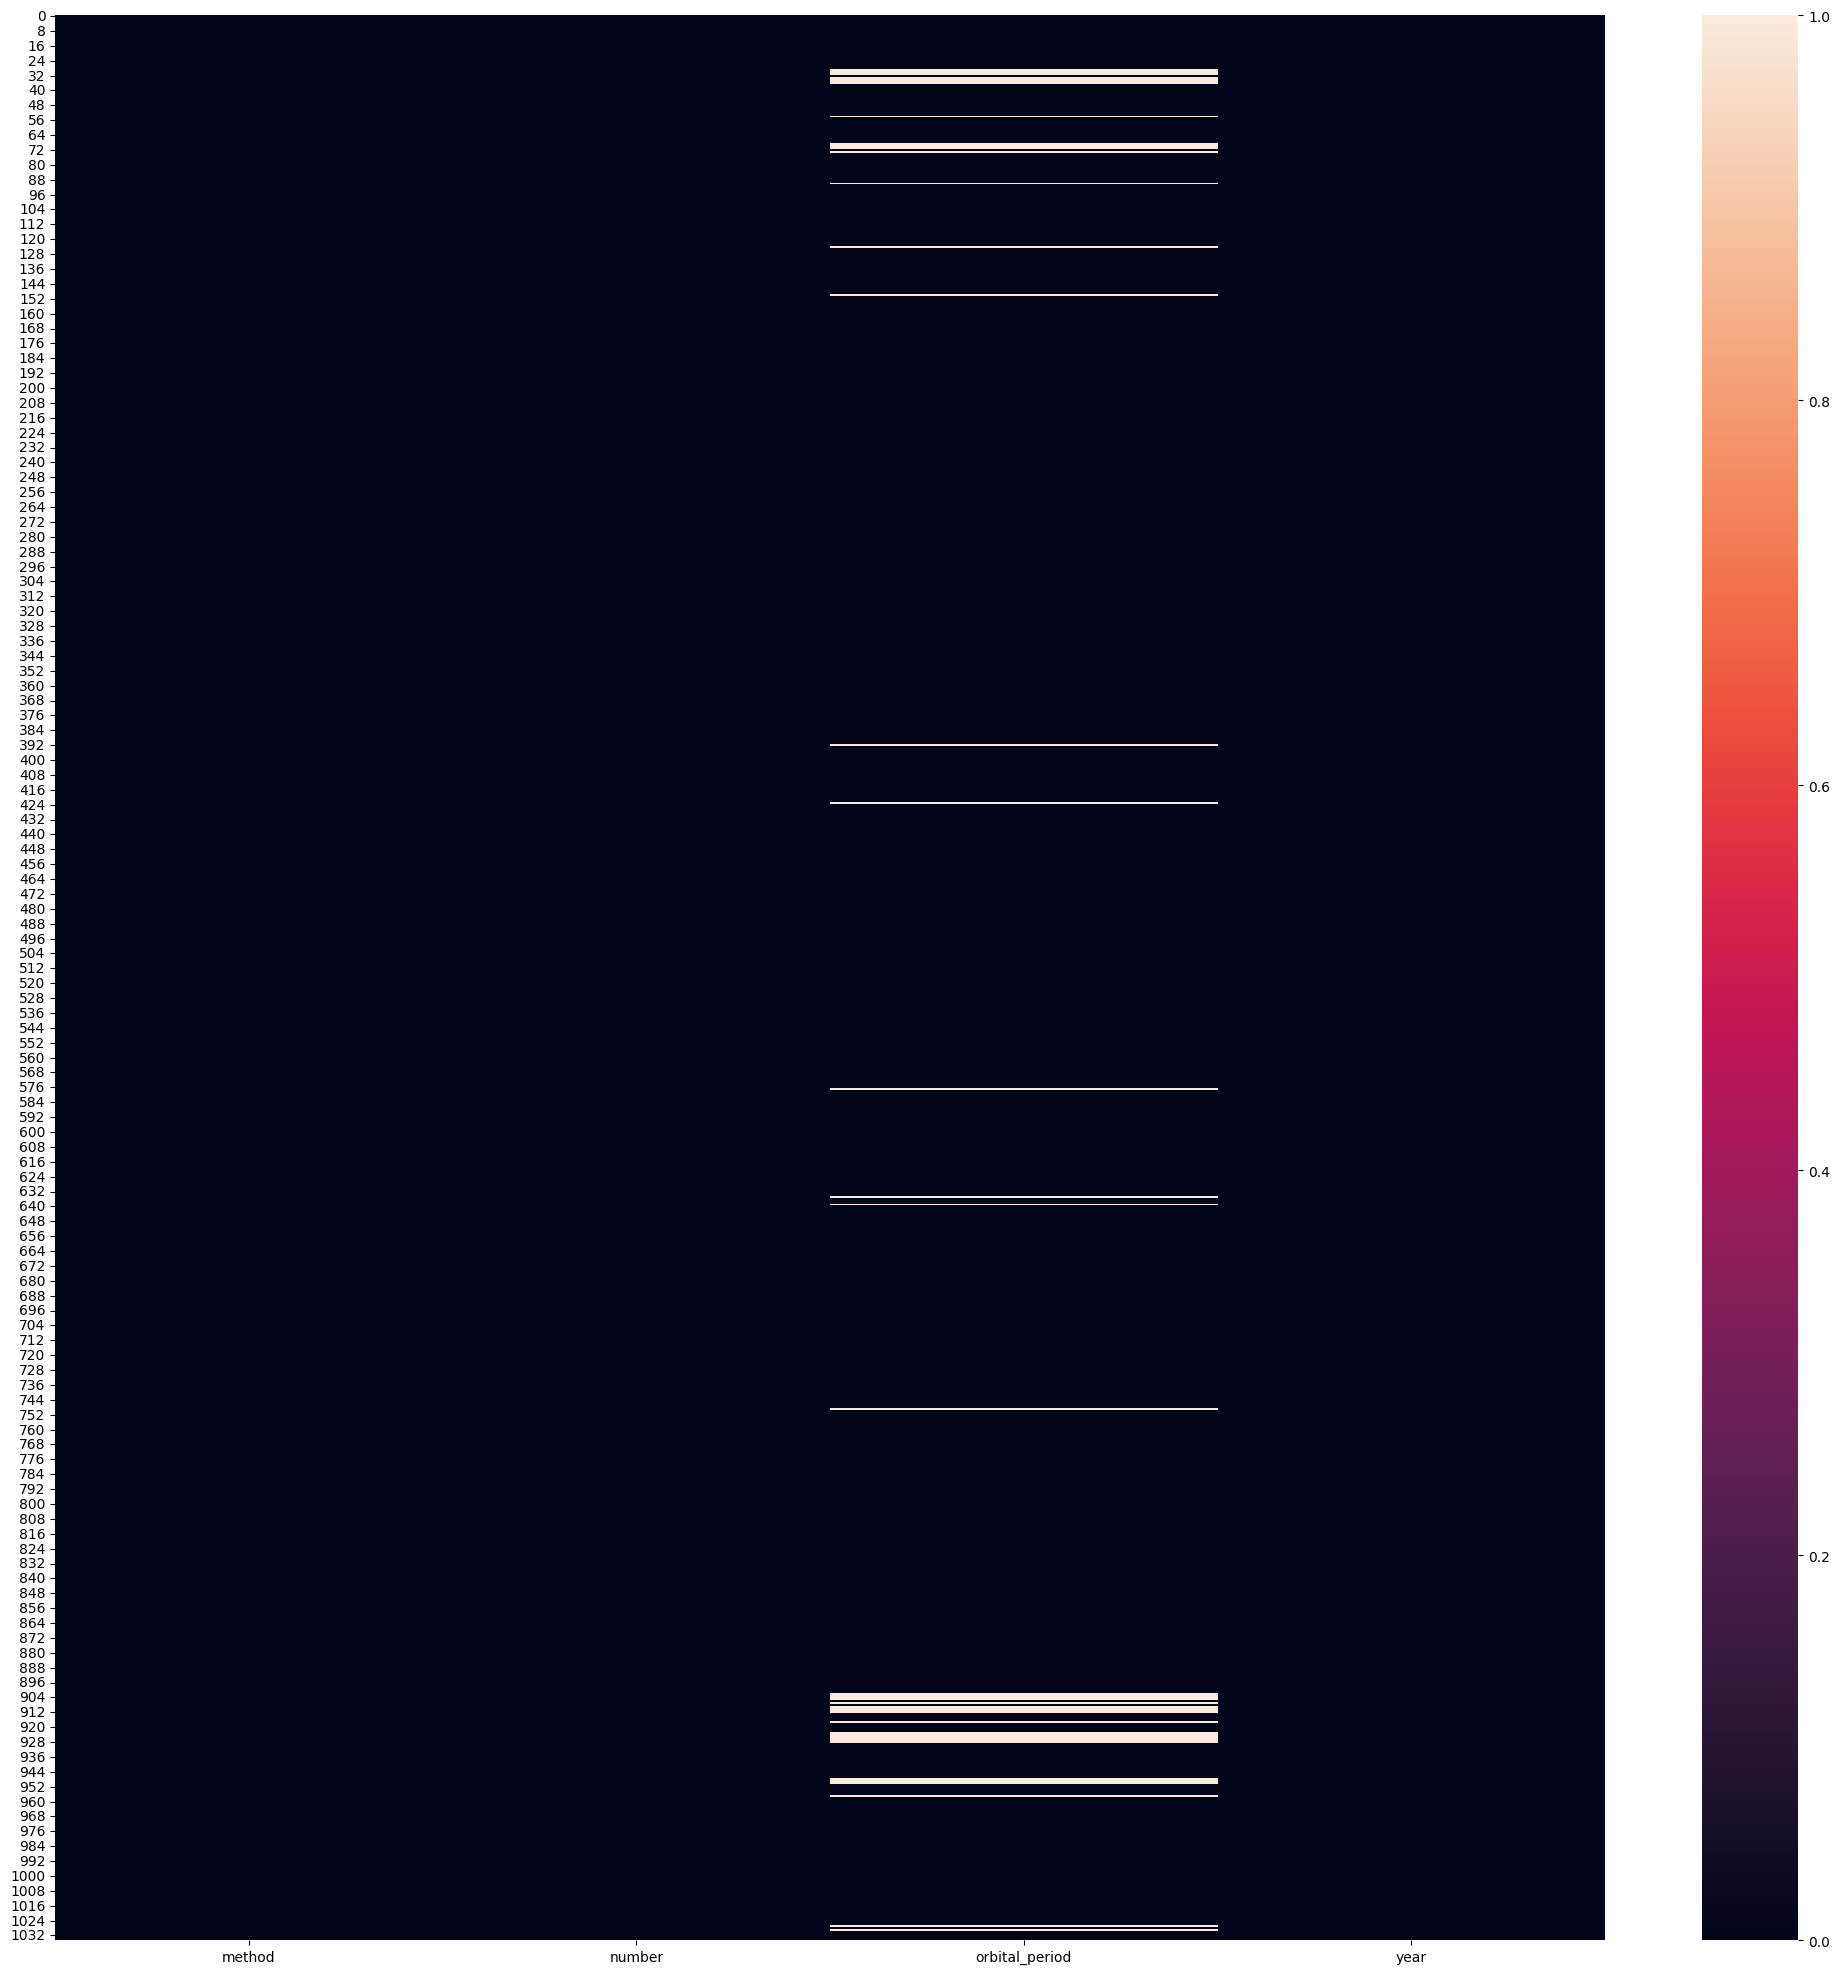

In [40]:
plt.figure(figsize = (25, 25))
sns.heatmap(df2_d_col.isnull())

In [41]:
df3_d_r = df2_d_col.dropna()
df3_d_r.shape

(992, 4)

<Axes: >

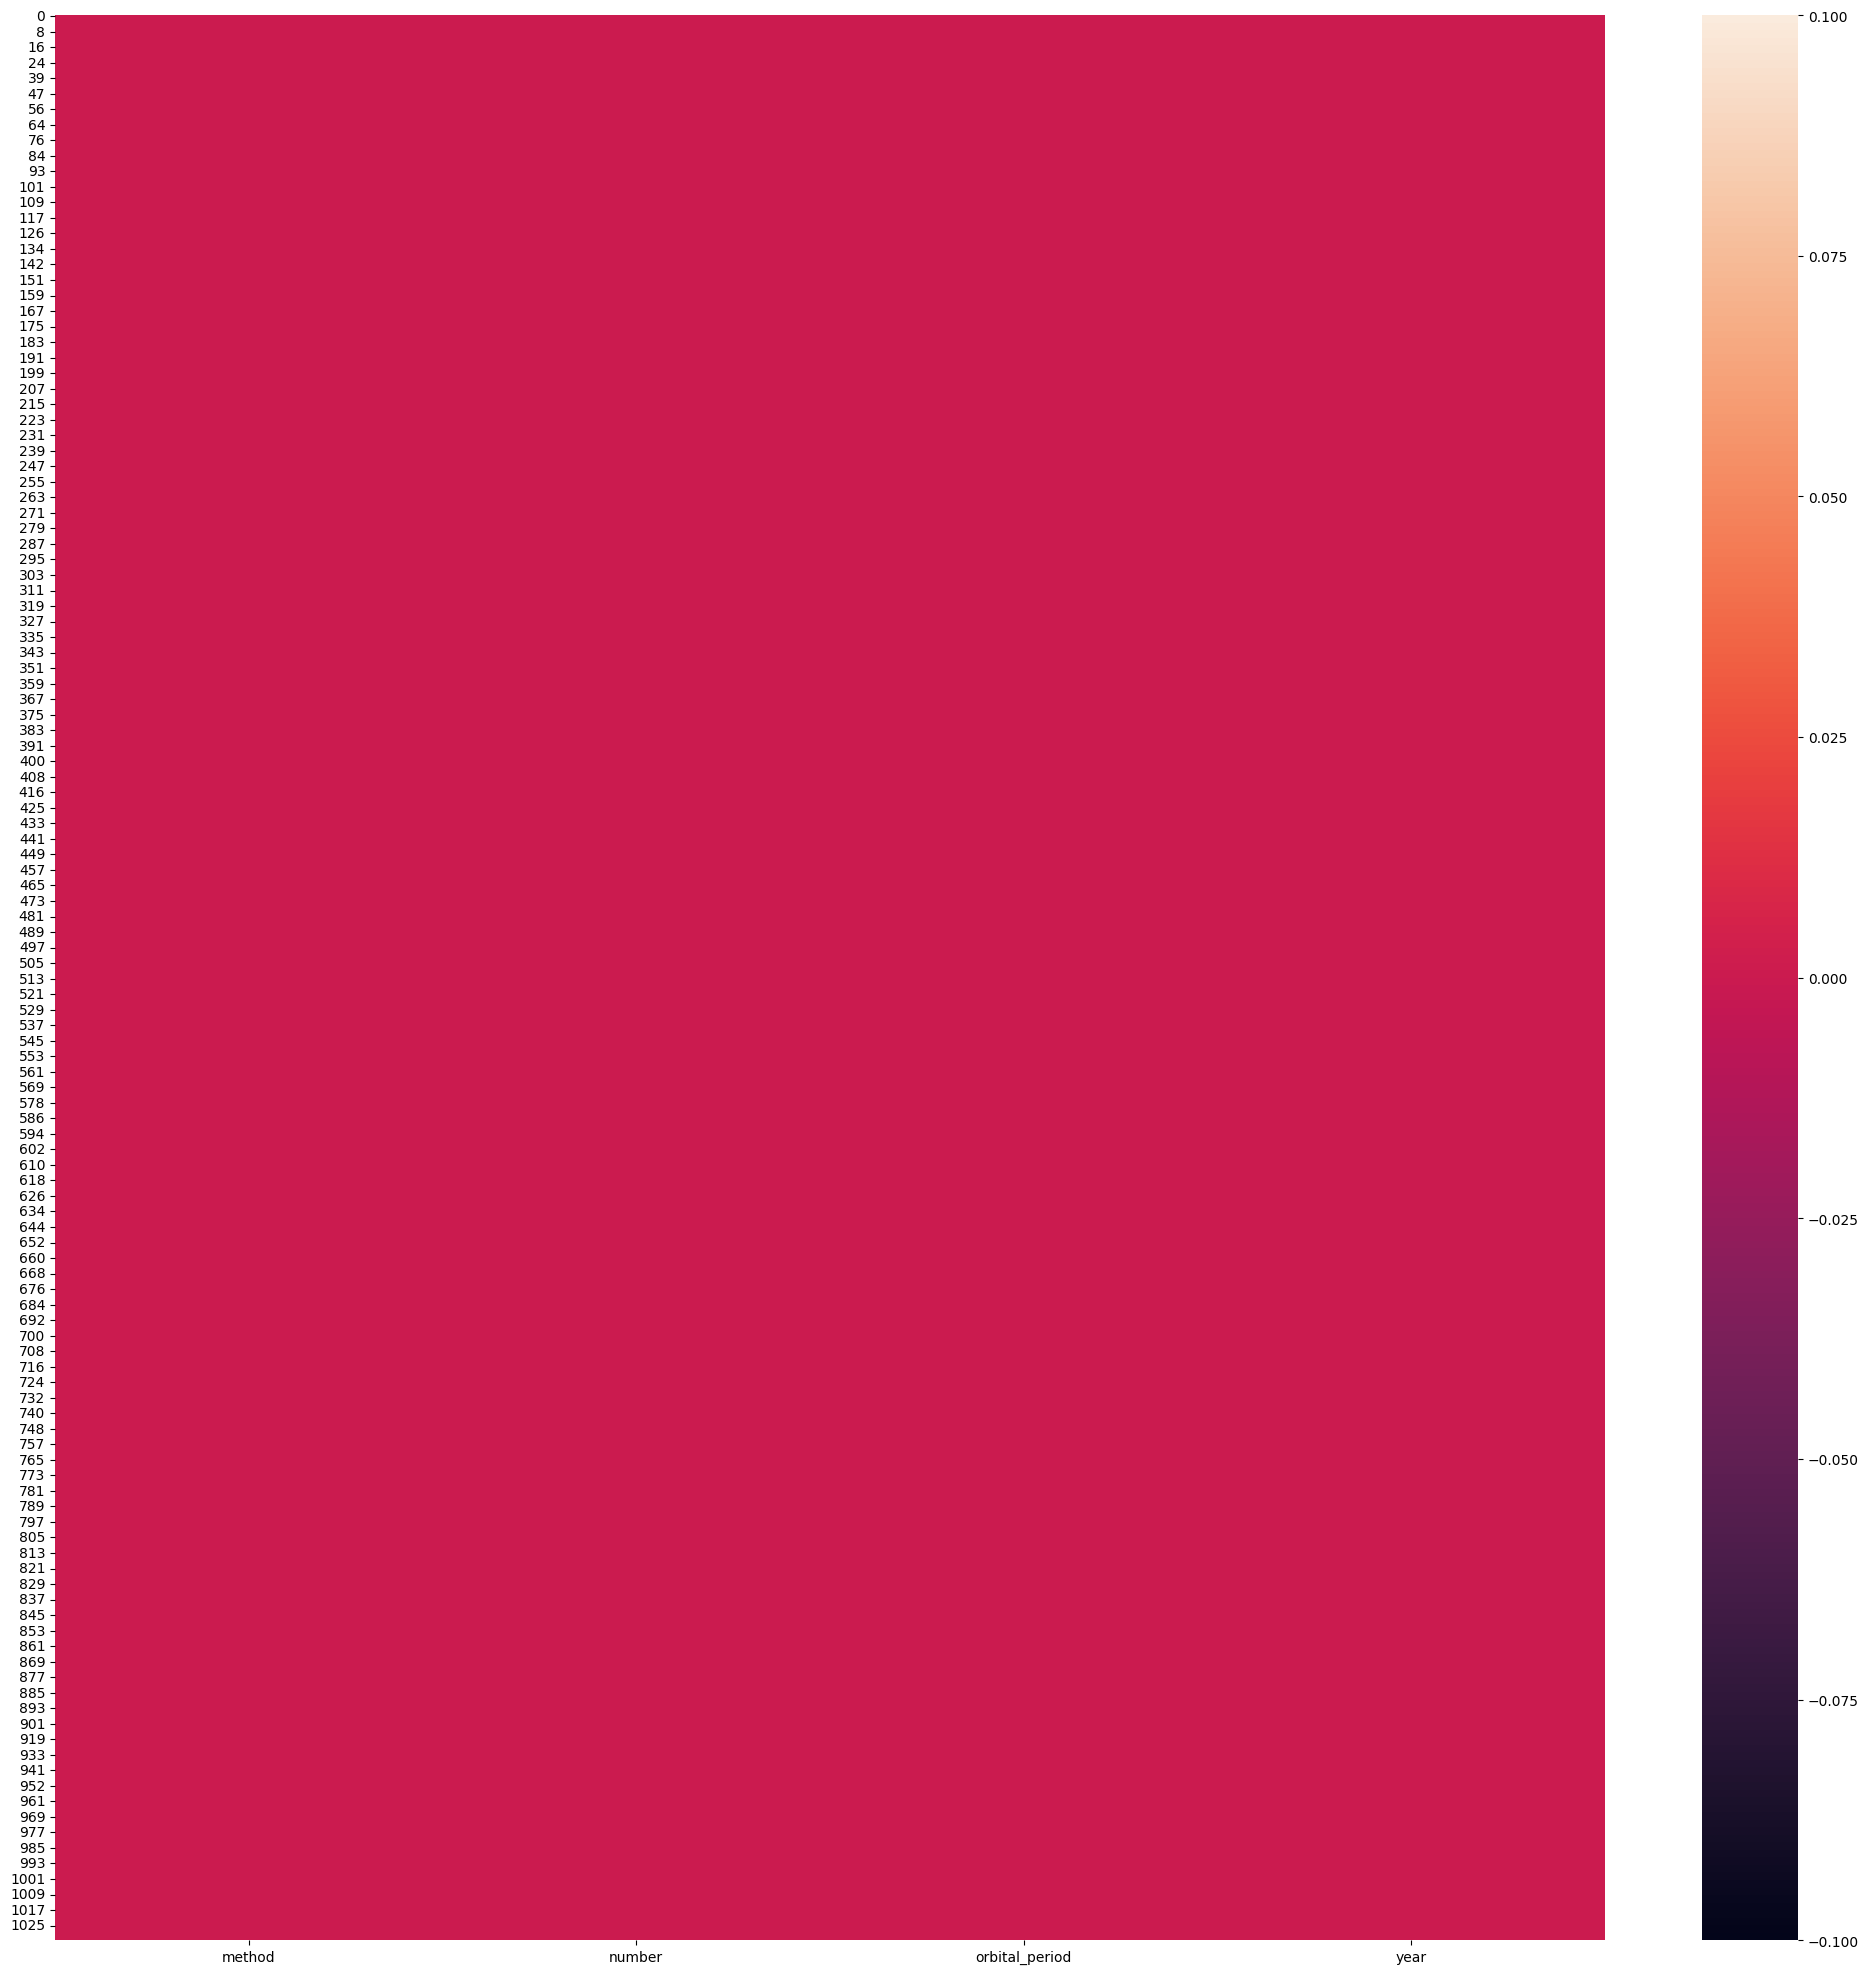

In [42]:
plt.figure(figsize = (25, 25))
sns.heatmap(df3_d_r.isnull())

In [43]:
df3_d_r.isnull().sum()

method            0
number            0
orbital_period    0
year              0
dtype: int64

In [44]:
df3_d_r.isnull().sum().sum()

np.int64(0)

In [46]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [47]:
df = sns.load_dataset("tips")

In [48]:
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [49]:
df.keys()

Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='str')

In [52]:
df2 = df[['sex', 'smoker', 'day', 'time']].copy()

In [53]:
df2

,sex,smoker,day,time
0,Female,No,Sun,Dinner
1,Male,No,Sun,Dinner
2,Male,No,Sun,Dinner
3,Male,No,Sun,Dinner
4,Female,No,Sun,Dinner
...,...,...,...,...
239,Male,No,Sat,Dinner
240,Female,Yes,Sat,Dinner
241,Male,Yes,Sat,Dinner
242,Male,No,Sat,Dinner


In [55]:
for col in df2.columns:
    df2[col] = le.fit_transform(df2[col])
df2

,sex,smoker,day,time
0,0,0,2,0
1,1,0,2,0
2,1,0,2,0
3,1,0,2,0
4,0,0,2,0
...,...,...,...,...
239,1,0,1,0
240,0,1,1,0
241,1,1,1,0
242,1,0,1,0


In [58]:
for col in ["sex", "smoker", "day", "time"]:
    df[col] = le.fit_transform(df[col])
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,0,0,2,0,2
1,10.34,1.66,1,0,2,0,3
2,21.01,3.50,1,0,2,0,3
3,23.68,3.31,1,0,2,0,2
4,24.59,3.61,0,0,2,0,4
...,...,...,...,...,...,...,...
239,29.03,5.92,1,0,1,0,3
240,27.18,2.00,0,1,1,0,2
241,22.67,2.00,1,1,1,0,2
242,17.82,1.75,1,0,1,0,2
